In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')


In [33]:
df= pd.read_csv(r"D:\ML Projects\Customer_churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

# EDA

In [34]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [35]:
df.shape

(7043, 21)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [37]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
for col in df.columns:
  print(f'{col} has {df[col].nunique()} unique values')

customerID has 7043 unique values
gender has 2 unique values
SeniorCitizen has 2 unique values
Partner has 2 unique values
Dependents has 2 unique values
tenure has 73 unique values
PhoneService has 2 unique values
MultipleLines has 3 unique values
InternetService has 3 unique values
OnlineSecurity has 3 unique values
OnlineBackup has 3 unique values
DeviceProtection has 3 unique values
TechSupport has 3 unique values
StreamingTV has 3 unique values
StreamingMovies has 3 unique values
Contract has 3 unique values
PaperlessBilling has 2 unique values
PaymentMethod has 4 unique values
MonthlyCharges has 1585 unique values
TotalCharges has 6531 unique values
Churn has 2 unique values


In [40]:
numerical_features = ["tenure", "MonthlyCharges", "customerID", "TotalCharges"]

for col in df.columns:
  if col not in numerical_features:
    print(col, df[col].unique())
    print("-"*40)

gender <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
----------------------------------------
SeniorCitizen [0 1]
----------------------------------------
Partner <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
Dependents <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------
PhoneService <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
----------------------------------------
MultipleLines <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----------------------------------------
InternetService <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
----------------------------------------
OnlineSecurity <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------------------------------------
OnlineBackup <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
-----------------------------

## Columns Distribution

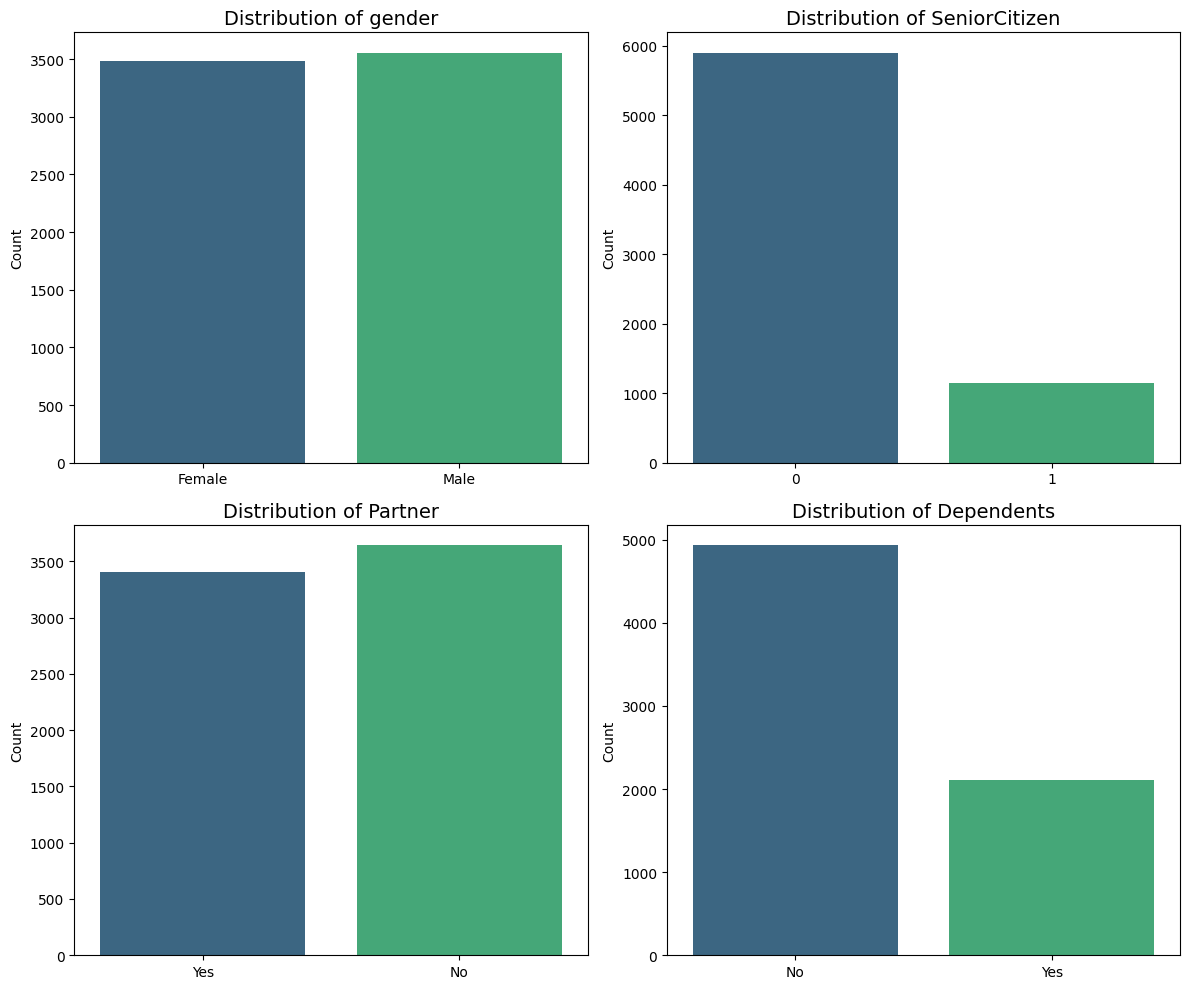

In [41]:
cols_part1 = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cols_part1):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

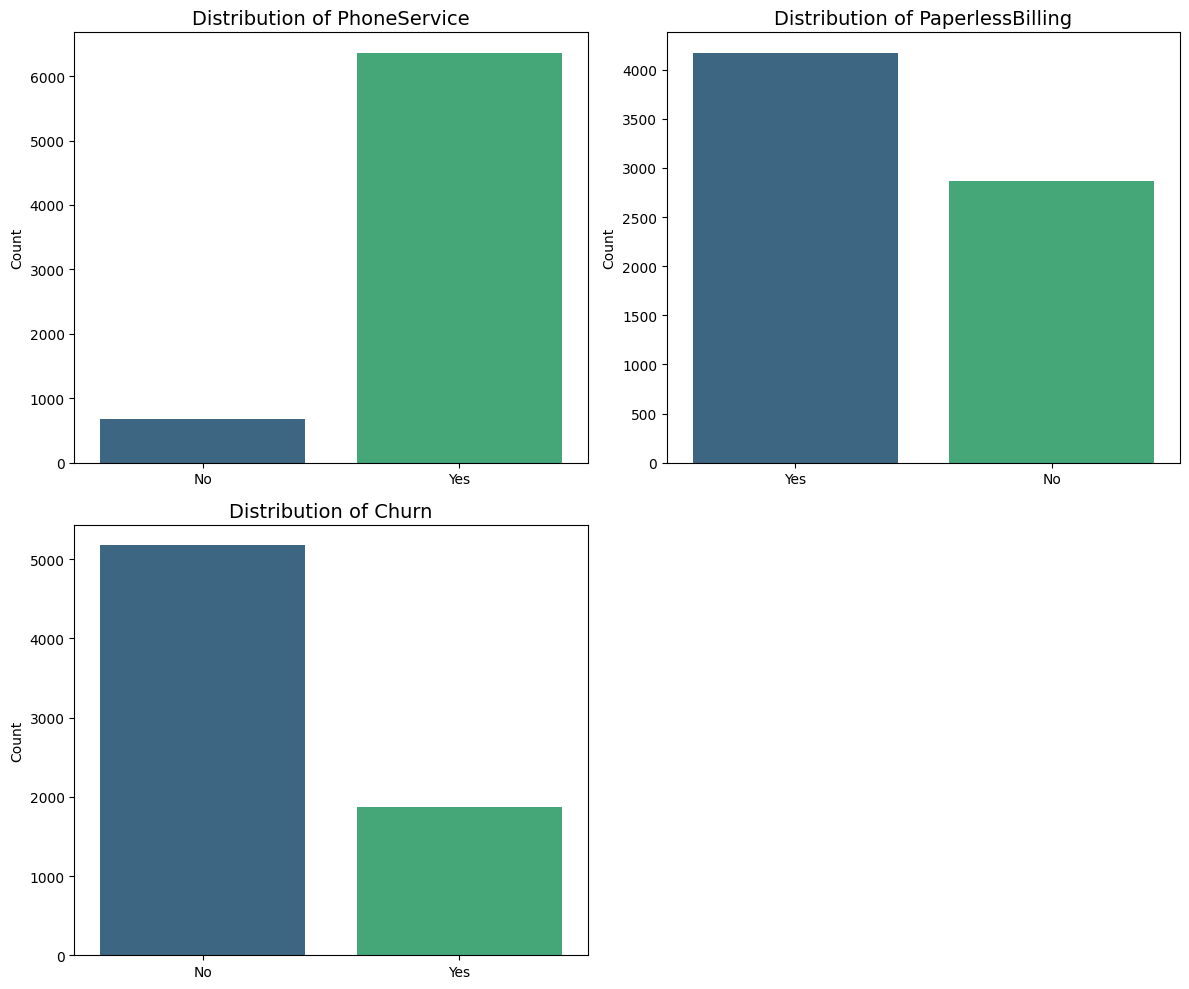

In [42]:
cols_part2 = ['PhoneService', 'PaperlessBilling', 'Churn']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(cols_part2):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

# delete the last visual because its null
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

## Churn

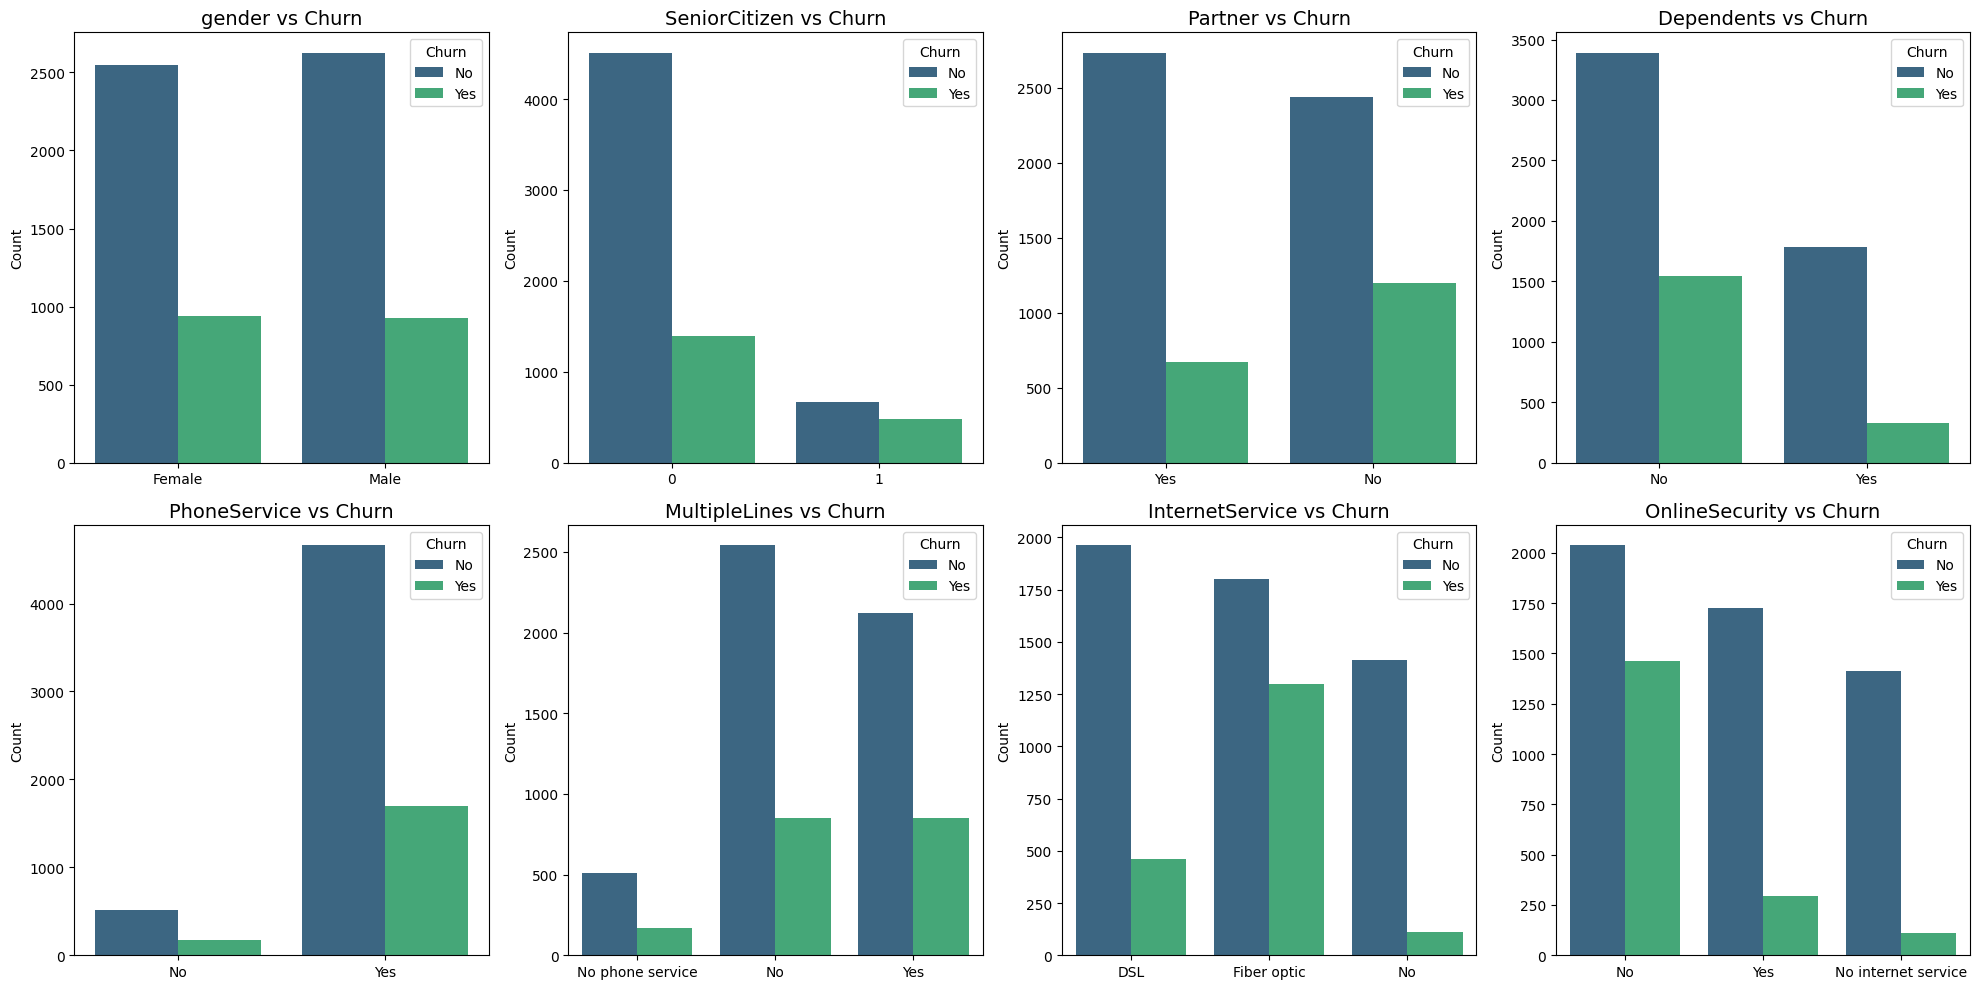

In [43]:
cols_part1 = ['gender','SeniorCitizen','Partner','Dependents','PhoneService','MultipleLines','InternetService','OnlineSecurity',]
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10)) # Changed ncols from 2 to 4
axes = axes.flatten()

for i, col in enumerate(cols_part1):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Churn', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

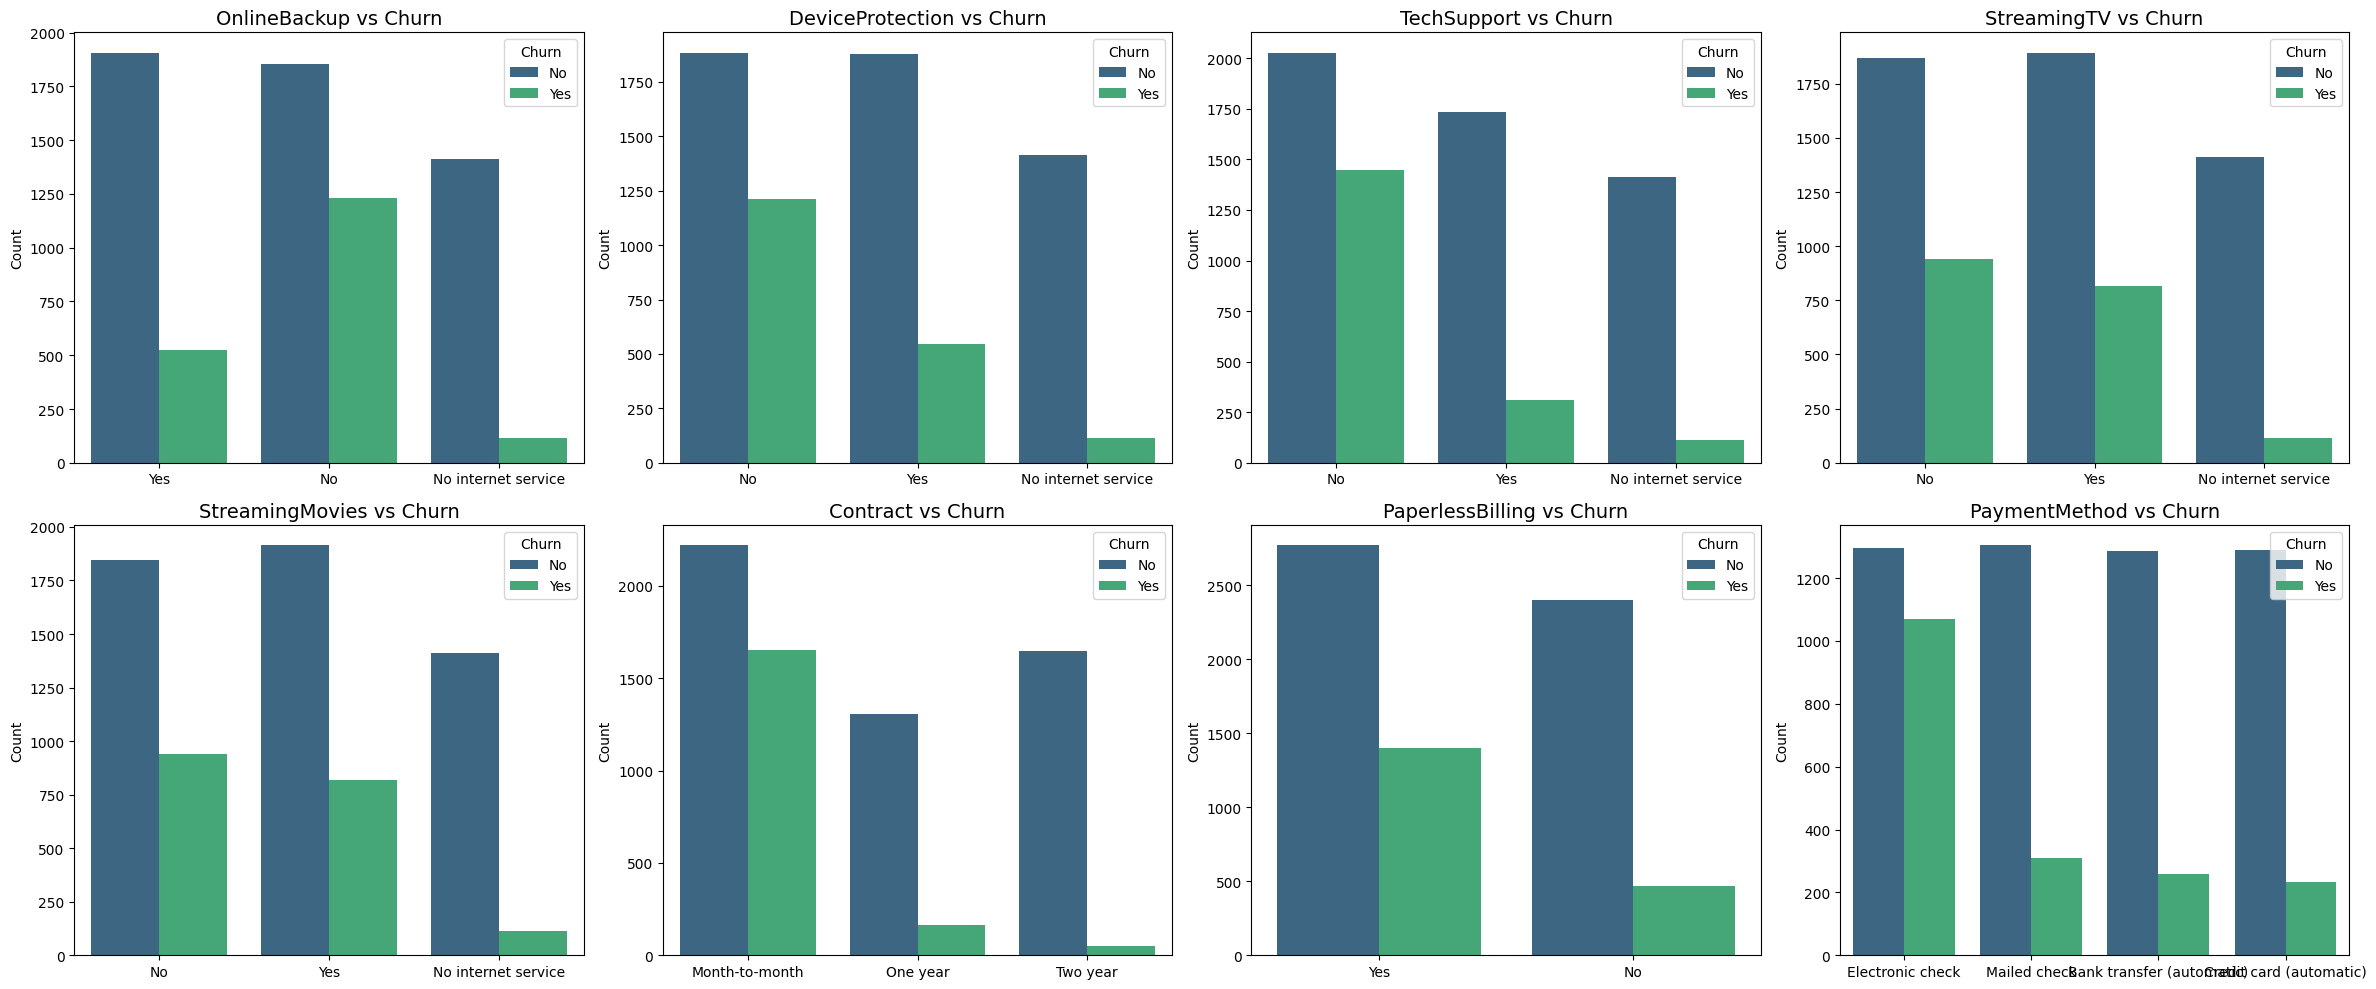

In [44]:
cols_part2 = ['OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaperlessBilling','PaymentMethod']

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))
axes = axes.flatten()

for i, col in enumerate(cols_part2):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} vs Churn', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Preprocessing & Feature Engineering

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [46]:
df.drop('customerID', axis=1, inplace=True)

In [ ]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'], errors= 'coerce')

In [ ]:
# create a new feature to capture the average monthly charges for each customer
df['AvgMonthlyCharges']= df['TotalCharges']/ (df['tenure'] +1)

In [ ]:
# create a new feature to capture the total number of services a customer has subscribed to
services = [
    'PhoneService','MultipleLines','InternetService',
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

df['TotalServices'] = (df[services] == 'Yes').sum(axis=1)

In [50]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharges,TotalServices
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,14.925000,1
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,One year,No,Mailed check,56.95,1889.50,No,53.985714,3
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,36.050000,3
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,40.016304,3
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,50.550000,1


In [51]:
X= df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

In [52]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)

In [ ]:
from pandas.core.arrays import categorical
numeric_features= ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgMonthlyCharges']
categorical_features= [col for col in X.columns if col not in numeric_features]

numeric_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
# Using OrdinalEncoder instead of OHE to prevent feature fragmentation in tree models
categorical_transformer= Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor= ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])


# Base Line

In [ ]:
# we used ImbPipeline to handle class imbalance with SMOTE, but we could also use class_weight in the classifier for a cleaner approach
model= ImbPipeline(steps=
                   [
                       ('preprocessor', preprocessor),
                      ('smote', SMOTE(random_state=42)),
                       ('classifier', LogisticRegression(random_state= 42, class_weight= 'balanced'))
                   ])
model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AvgMonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OrdinalEncoder(handle_u...
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [56]:
y_pred= model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



### Random Forest

In [57]:
rf_model= ImbPipeline(steps=
                   [
                       ('preprocessor', preprocessor),
                      ('smote', SMOTE(random_state=42)),
                      ('classifier', RandomForestClassifier(n_estimators= 600,random_state= 42, class_weight= 'balanced'))
                   ])
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AvgMonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OrdinalEncoder(handle_u...
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=600, random_state=42))])

In [58]:
y_pred1= rf_model.predict(X_test)
print(classification_report(y_test, y_pred1))

              precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.58      0.57       374

    accuracy                           0.77      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.77      0.77      0.77      1409



### XGBOOST

In [ ]:
# Handle class imbalance natively using scale_pos_weight (faster & cleaner than SMOTE)
neg_class_count= (y_train == 0).sum()
pos_class_count= (y_train == 1).sum()
scale_weight= neg_class_count/pos_class_count
# Build pipeline with best parametrs from RandomizedSearchCV 
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        scale_pos_weight=scale_weight,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.01,
        subsample=0.6,
        colsample_bytree=1.0,
        min_child_weight=3,
        random_state=42,
        eval_metric='logloss'
    ))
])
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'TotalServices',
                                                   'AvgMonthlyCharges']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OrdinalEncoder(handle_u...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.01,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=3,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300,
                               n_jobs=None, num_parallel_tree=None, ...))])

In [ ]:
# Evaluation focuses on Recall for Class 1 
# (Business context: cost of a False Negative is higher than a False Positive
y_pred_xgb = xgb_pipeline.predict(X_test)
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.91      0.76      0.83      1035
           1       0.54      0.78      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409



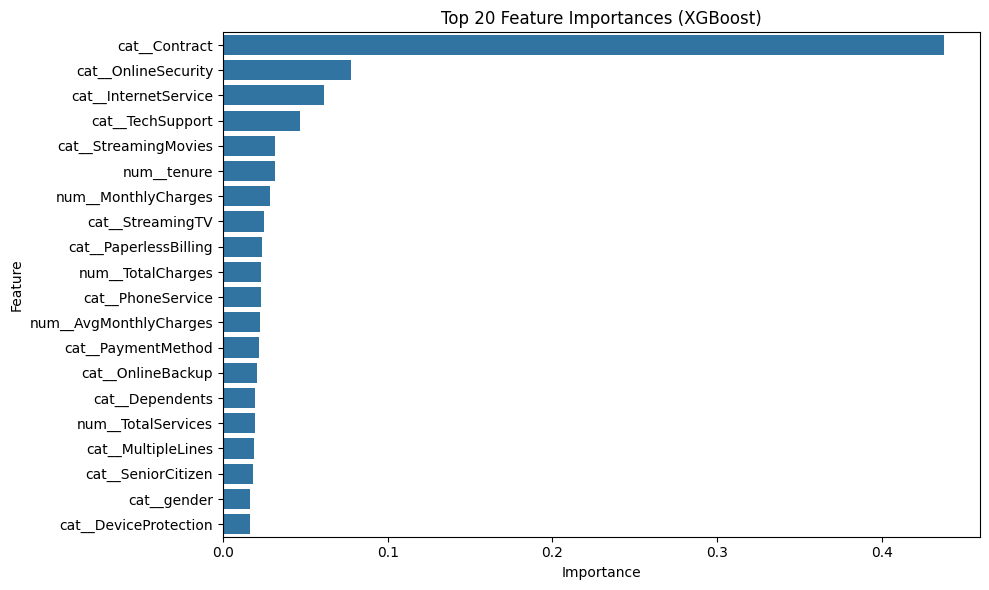

In [ ]:
# Extract feature importances from the XGBoost model
feature_importances = xgb_pipeline.named_steps['classifier'].feature_importances_
# get feature names
feature_names = xgb_pipeline.named_steps['preprocessor'].get_feature_names_out()
# create dataframe
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})
# sort
fi_df = fi_df.sort_values(by='importance', ascending=False)
# top 20 features
top_n = 20
fi_df_top = fi_df.head(top_n)
# plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=fi_df_top,
    x='importance',
    y='feature'
)
plt.title('Top 20 Feature Importances (XGBoost)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()